In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Đọc và gộp 2 tập dữ liệu
df_mat = pd.read_csv('Data/student-mat.csv', sep=';')
df_por = pd.read_csv('Data/student-por.csv', sep=';')

df_mat['subject'] = 'Math'
df_por['subject'] = 'Por'
df = pd.concat([df_mat, df_por], ignore_index=True)

print(f"Tổng số học sinh: {df.shape[0]}")
print(f"Số lượng cột (chiều dữ liệu ban đầu): {df.shape[1]}")

Tổng số học sinh: 1044
Số lượng cột (chiều dữ liệu ban đầu): 34


In [2]:
df_pca = df.copy()

# Xử lý biến phân loại (Categorical)
categorical_cols = df_pca.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df_pca[col] = le.fit_transform(df_pca[col])

# Tách Features (X) và Target (y)
# Drop G1, G2, G3 khỏi tập features cần giảm chiều
X = df_pca.drop(['G1', 'G2', 'G3'], axis=1)
y_g3 = df_pca['G3']  # Lưu lại G3 để lát nữa tô màu

# CHUẨN HÓA DỮ LIỆU BẰNG STANDARD SCALER
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dữ liệu đã được chuẩn hóa (Mean=0, Variance=1).")

Dữ liệu đã được chuẩn hóa (Mean=0, Variance=1).


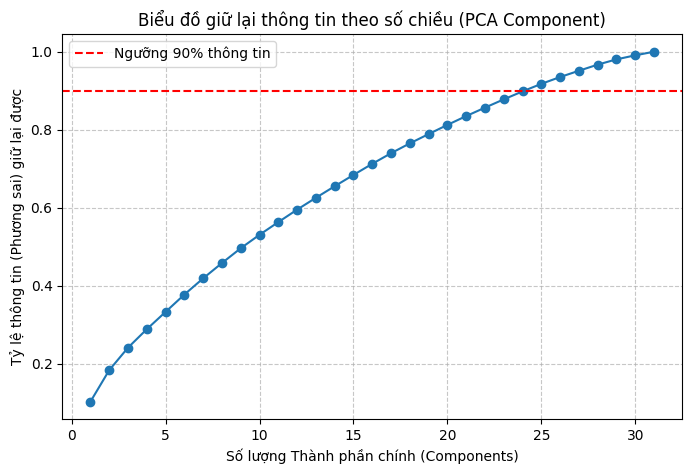

In [3]:
# Chạy thử PCA với toàn bộ số lượng đặc trưng gốc
pca_full = PCA(n_components=X_scaled.shape[1])
pca_full.fit(X_scaled)

# Tính tổng phần trăm thông tin giữ lại được khi thêm dần các chiều
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.axhline(y=0.90, color='r', linestyle='--', label='Ngưỡng 90% thông tin')

plt.title('Biểu đồ giữ lại thông tin theo số chiều (PCA Component)')
plt.xlabel('Số lượng Thành phần chính (Components)')
plt.ylabel('Tỷ lệ thông tin (Phương sai) giữ lại được')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

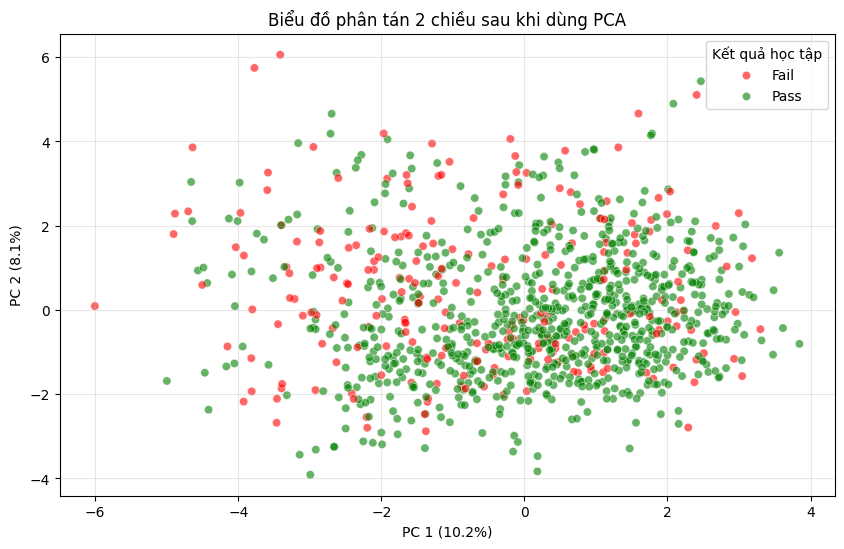

In [4]:
# Giảm xuống còn đúng 2 chiều
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Tạo DataFrame mới từ kết quả PCA để dễ vẽ
df_pca_result = pd.DataFrame(data = X_pca_2d, columns = ['PC1', 'PC2'])

# Thêm biến phân loại: Đỗ (>=10) và Trượt (<10) để xem 2 nhóm này có tách biệt nhau trên mặt phẳng 2D không
df_pca_result['Pass_Fail'] = y_g3.apply(lambda x: 'Pass' if x >= 10 else 'Fail')

# Vẽ biểu đồ Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Pass_Fail',
    palette={'Pass': 'green', 'Fail': 'red'},
    data=df_pca_result,
    alpha=0.6
)

plt.title('Biểu đồ phân tán 2 chiều sau khi dùng PCA')
plt.xlabel(f'PC 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Kết quả học tập')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Lấy trọng số của từng cột gốc đóng góp vào PC1
components_df = pd.DataFrame(pca_2d.components_, columns=X.columns, index=['PC1', 'PC2'])

# Lấy 5 yếu tố có sức ảnh hưởng mạnh nhất tới PC1 (lấy giá trị tuyệt đối)
top_pc1_features = components_df.loc['PC1'].abs().sort_values(ascending=False).head(5)

print("5 Đặc trưng đóng góp nhiều nhất vào Thành phần chính số 1 (PC1):")
print(top_pc1_features)

5 Đặc trưng đóng góp nhiều nhất vào Thành phần chính số 1 (PC1):
Medu      0.396049
Fedu      0.350791
school    0.302815
Mjob      0.284882
higher    0.258056
Name: PC1, dtype: float64
